# 🏎️ Red Bull F1 Performance Analysis

## 📌 Introduction
This project performs an exploratory data analysis (EDA) of Red Bull Racing's Formula 1 performance over multiple seasons. Using historical race data, we examine patterns in driver performance, qualifying positions, and overall race outcomes. The goal is to understand what makes Red Bull one of the most dominant teams in recent F1 history and what trends emerge from their race strategy and execution.

Key Questions Explored:
- How has Red Bull's race performance evolved over the years?
- What is the correlation between qualifying position and race result?
- How do Red Bull drivers compare with others on the grid?

## ❓ Problem Statement

Formula 1 is a sport driven by both human performance and machine precision. Red Bull Racing has shown consistent dominance in recent seasons. This analysis investigates:

- What trends exist in Red Bull Racing’s race performance?
- How have individual drivers (like Max Verstappen and Sergio Pérez) contributed?
- Are there any standout patterns in race wins, qualifying, or pit stop strategies?
- How does Red Bull compare to other top constructors like Mercedes or Ferrari?

The goal is to derive meaningful insights through data visualization and interpretation.


## 📂 Data Source

This notebook uses Formula 1 racing datasets from the [Ergast Developer API](https://ergast.com/mrd/), a well-known open-access motorsport data source. The data is commonly distributed via Kaggle or GitHub repositories.

For this project, the datasets were sourced from the [F1 World GitHub Repository](https://github.com/ergast/f1db), which hosts the structured CSV files derived from the API.

The key CSV files used in this analysis are:

- `races.csv` — Contains metadata for each Grand Prix, including year, round, date, and circuit information.  
- `results.csv` — Records detailed race results such as finishing position, points earned, and constructor/driver associations.
- `drivers.csv` — Provides driver details like name, nationality, and career info.
- `constructors.csv` — Includes information about teams/constructors such as name and nationality.

> 🧹 These datasets have been minimally cleaned and filtered to focus on Red Bull Racing and comparisons with other top teams such as Mercedes and Ferrari.


In [108]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display and plotting styles
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


## 🧹 Data Loading & Cleaning
We begin by importing and cleaning the dataset to prepare it for exploration and modeling.

In [122]:

# Load F1 datasets
races = pd.read_csv("../data/races.csv")
results = pd.read_csv("../data/results.csv")
constructors = pd.read_csv("../data/constructors.csv")
drivers = pd.read_csv("../data/drivers.csv")

# Preview the datasets
print("Races:", races.shape)
print("Results:", results.shape)
print("Constructors:", constructors.shape)
print("Drivers:", drivers.shape)

race_counts = {
    2009: 17,
    2010: 19,
    2011: 19,
    2012: 20,
    2013: 19,
    2014: 19,
    2015: 19,
    2016: 21,
    2017: 20,
    2018: 21,
    2019: 21,
    2020: 17,
    2021: 22,
    2022: 22,
    2023: 22
}




Races: (1125, 18)
Results: (26759, 18)
Constructors: (212, 5)
Drivers: (861, 9)


In [110]:
# Helper functions for filtering and merging

def get_red_bull_results(results_df, constructors_df):
    """Returns all race results where the constructor is Red Bull Racing."""
    merged = results_df.merge(constructors_df, on="constructorId")
    red_bull = merged[merged["name"].str.contains("Red Bull", case=False, na=False)]
    return red_bull

def get_driver_full_name(driver_row):
    """Returns full name of a driver."""
    return f"{driver_row['forename']} {driver_row['surname']}"

def get_driver_id_by_name(drivers_df, name):
    """Returns the driverId for a given full name."""
    drivers_df["full_name"] = drivers_df.apply(get_driver_full_name, axis=1)
    matched = drivers_df[drivers_df["full_name"].str.contains(name, case=False, na=False)]
    if not matched.empty:
        return matched.iloc[0]["driverId"]
    else:
        return None

def get_driver_results(results_df, drivers_df, driver_name):
    """Returns all race results for a specific driver."""
    driver_id = get_driver_id_by_name(drivers_df, driver_name)
    if driver_id is not None:
        return results_df[results_df["driverId"] == driver_id]
    else:
        print(f"No driver found for name: {driver_name}")
        return pd.DataFrame()


## Exploratory Data Analysis (EDA)
We'll visualize important metrics like driver points, podium finishes, and track performance.

In [81]:
print("Races")
display(races.head())

Races


,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


In [82]:
print("Results")
display(results.head())

Results


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1


In [83]:
print("Constructors")
display(constructors.head(10))

Constructors


,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso
5,6,ferrari,Ferrari,Italian,http://en.wikipedia.org/wiki/Scuderia_Ferrari
6,7,toyota,Toyota,Japanese,http://en.wikipedia.org/wiki/Toyota_Racing
7,8,super_aguri,Super Aguri,Japanese,http://en.wikipedia.org/wiki/Super_Aguri_F1
8,9,red_bull,Red Bull,Austrian,http://en.wikipedia.org/wiki/Red_Bull_Racing
9,10,force_india,Force India,Indian,http://en.wikipedia.org/wiki/Racing_Point_Forc...


In [84]:
print("Drivers")
display(drivers.head())

Drivers


,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [85]:
constructors[constructors["name"].str.contains("Red Bull", case = False)]

,constructorId,constructorRef,name,nationality,url
8,9,red_bull,Red Bull,Austrian,http://en.wikipedia.org/wiki/Red_Bull_Racing


In [86]:
redbull_results = results[results["constructorId"]==9]
redbull_results = pd.merge(redbull_results,races, on = "raceId",suffixes=('', '_race'))

In [87]:
print(redbull_results.shape)

(788, 35)


In [ ]:
redbull_drivers = redbull_results['driverId'].unique()
redbull_driver_info =drivers[drivers["driverId"].isin(redbull_drivers)]
redbull_driver_info.to_csv("redbull_drivers.csv", index=False)

In [145]:
redbull_results_only = results[results['driverId'].isin(redbull_driver_info['driverId'])]
# Join race info
merged = redbull_results_only.merge(races, on='raceId')

# Example: points per driver
driver_points = redbull_results_only.groupby('driverId')['points'].sum().sort_values(ascending=False)

years_per_driver = merged.groupby(['driverId', 'year'])['raceId'].nunique().reset_index(name='races_count')


In [88]:
redbull_results.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,round,circuitId,name,date,time_race,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,14,18,14,9,9,8,\N,R,14,0.0,25,\N,\N,21,11,1:29.502,213.300,4,2008,1,1,Australian Grand Prix,2008-03-16,04:30:00,http://en.wikipedia.org/wiki/2008_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,17,18,17,9,10,14,\N,R,17,0.0,0,\N,\N,\N,\N,\N,\N,4,2008,1,1,Australian Grand Prix,2008-03-16,04:30:00,http://en.wikipedia.org/wiki/2008_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,29,19,17,9,10,6,7,7,7,2.0,56,+1:08.130,5546685,53,12,1:36.696,206.366,1,2008,2,2,Malaysian Grand Prix,2008-03-23,07:00:00,http://en.wikipedia.org/wiki/2008_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,31,19,14,9,9,12,9,9,9,0.0,56,+1:16.220,5554775,55,9,1:36.206,207.417,1,2008,2,2,Malaysian Grand Prix,2008-03-23,07:00:00,http://en.wikipedia.org/wiki/2008_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,51,20,17,9,10,11,7,7,7,2.0,57,+45.473,5512443,51,8,1:34.305,206.597,1,2008,3,3,Bahrain Grand Prix,2008-04-06,11:30:00,http://en.wikipedia.org/wiki/2008_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


In [89]:
print(redbull_results.columns)

Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid',
       'position', 'positionText', 'positionOrder', 'points', 'laps', 'time',
       'milliseconds', 'fastestLap', 'rank', 'fastestLapTime',
       'fastestLapSpeed', 'statusId', 'year', 'round', 'circuitId', 'name',
       'date', 'time_race', 'url', 'fp1_date', 'fp1_time', 'fp2_date',
       'fp2_time', 'fp3_date', 'fp3_time', 'quali_date', 'quali_time',
       'sprint_date', 'sprint_time'],
      dtype='object')


In [90]:
print(redbull_results["year"].unique())

[2008 2007 2006 2005 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018
 2019 2020 2021 2022 2023 2024]


In [91]:
grouped = redbull_results.groupby("year")["points"].sum().reset_index()
grouped= grouped.rename(columns = {"points": "Total Points"})

In [92]:
wins = redbull_results[redbull_results["positionOrder"]==1]
annual_win_count= wins.groupby("year").size().reset_index(name="wins")

annual_win_count.head()

,year,wins
0,2009,6
1,2010,9
2,2011,12
3,2012,7
4,2013,13


In [93]:
podiums = redbull_results[redbull_results["positionOrder"]<=3]
annual_podium_count= podiums.groupby("year").size().reset_index(name ="podiums")

annual_podium_count.head()

,year,podiums
0,2006,1
1,2007,1
2,2008,1
3,2009,16
4,2010,20


In [123]:
Season_Summary = pd.merge(grouped,annual_win_count,on="year")
Season_Summary= pd.merge(Season_Summary, annual_podium_count, on='year')
Season_Summary["races"] = Season_Summary["year"].map(race_counts)
Season_Summary.head()

,year,Total Points,wins,podiums,races
0,2009,153.5,6,16,17.0
1,2010,498.0,9,20,19.0
2,2011,650.0,12,27,19.0
3,2012,460.0,7,14,20.0
4,2013,596.0,13,24,19.0


In [95]:
cleaned_redbull_results = redbull_results[["year","round", "name", "circuitId", "driverId", "points", "positionOrder", "grid", "statusId","fastestLapTime", "laps"]].reset_index(drop=True)

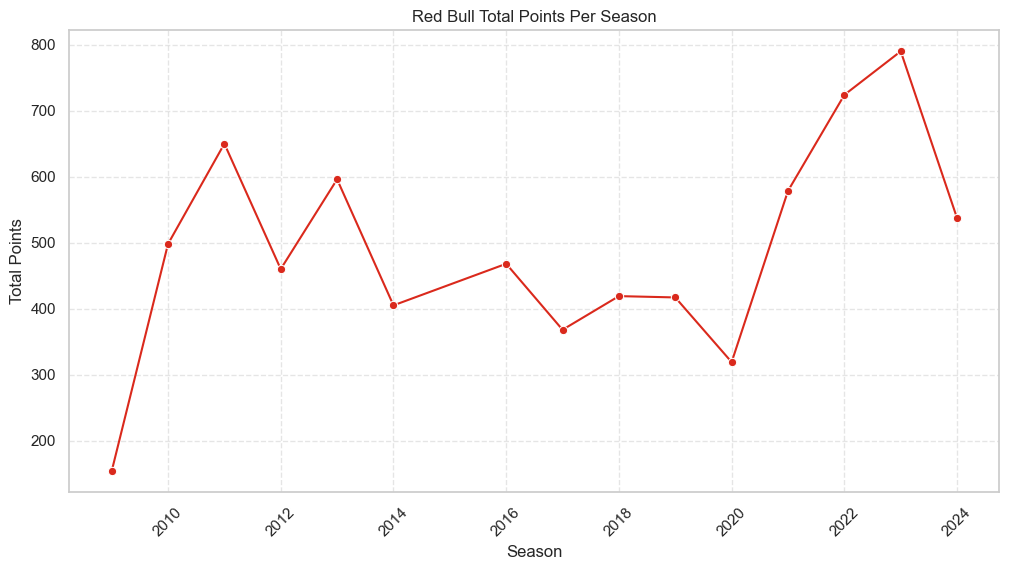

In [112]:
sns.lineplot(data=Season_Summary, x = "year", y = "Total Points",marker="o", color="#DA291C")
plt.xticks(rotation = 45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.title("Red Bull Total Points Per Season")
plt.xlabel("Season")
plt.ylabel("Total Points")
plt.savefig("/Users/tanvi/Desktop/redbull_f1_eda/figures/totalpoints_per_season.png", dpi=300, bbox_inches="tight")
plt.show()


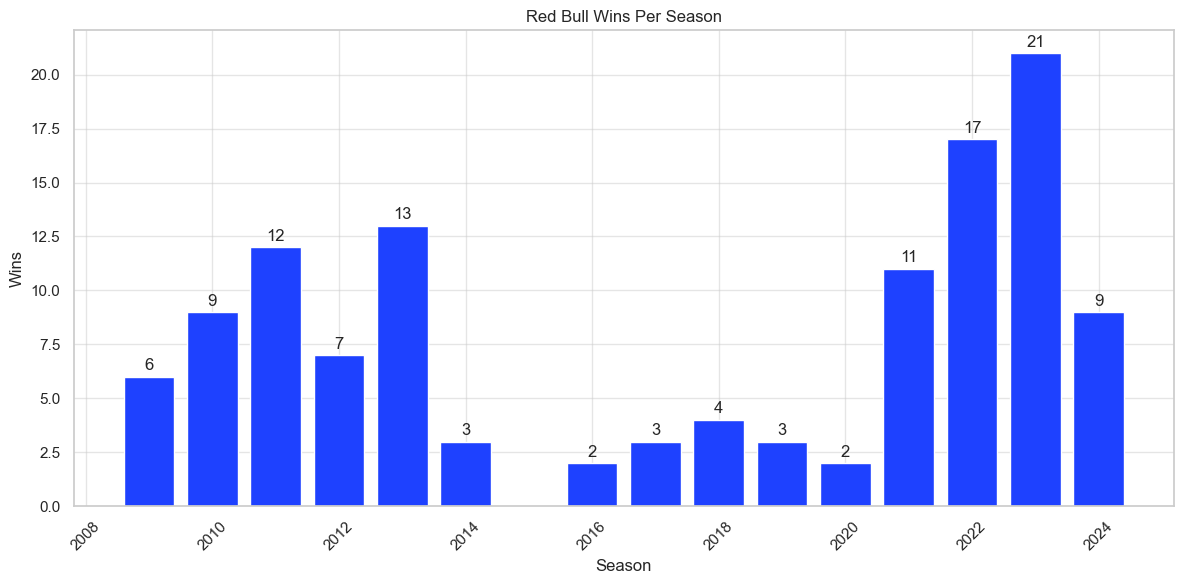

In [ ]:
plt.bar(Season_Summary["year"], Season_Summary["wins"], color="#1E41FF")
plt.title("Red Bull Wins Per Season")

# Annotate bars
for i, val in enumerate(Season_Summary["wins"]):
    plt.text(Season_Summary["year"][i], val + 0.3, str(val), ha='center')

plt.xlabel("Season")
plt.ylabel("Wins")
plt.xticks(rotation=45)
plt.grid(True, linestyle="-", alpha=0.5)

plt.tight_layout()  
plt.savefig("/Users/tanvi/Desktop/redbull_f1_eda/figures/wins_per_season.png", dpi=300, bbox_inches="tight")
plt.show()


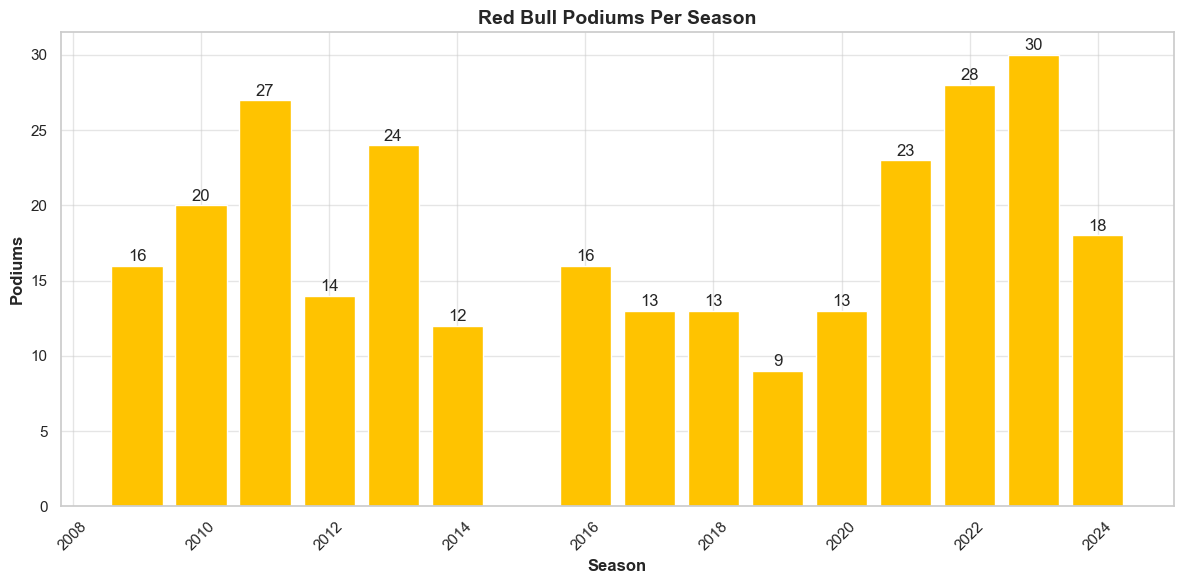

In [119]:
plt.bar(Season_Summary["year"],Season_Summary["podiums"],color = "#FFC300")
plt.title("Red Bull Podiums Per Season",fontsize=14, fontweight='bold')
for i, val in enumerate(Season_Summary["podiums"]):
    plt.text(Season_Summary["year"][i], val + 0.3, str(val), ha='center')

plt.xlabel("Season",fontsize=12, fontweight='bold')
plt.ylabel("Podiums",fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, linestyle="-", alpha=0.5)
plt.tight_layout()  
plt.savefig("/Users/tanvi/Desktop/redbull_f1_eda/figures/podiums_per_season.png", dpi=300, bbox_inches="tight")
plt.show()



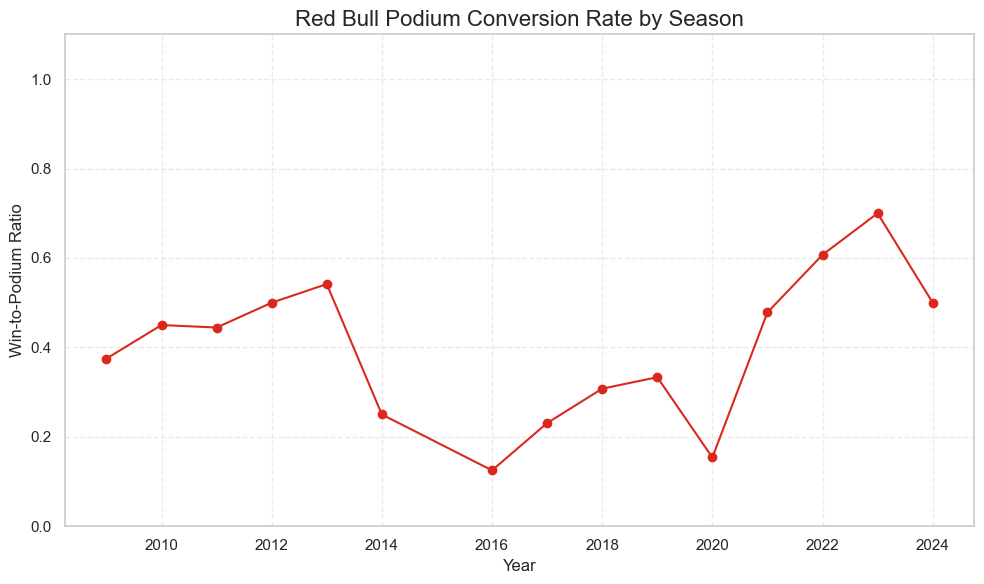

In [132]:
Season_Summary["podium_conversion"] = Season_Summary["wins"] / Season_Summary["podiums"]

plt.figure(figsize=(10, 6))
plt.plot(Season_Summary["year"], Season_Summary["podium_conversion"], marker='o', color='#DA291C')
plt.title("Red Bull Podium Conversion Rate by Season", fontsize=16)
plt.ylabel("Win-to-Podium Ratio")
plt.xlabel("Year")
plt.ylim(0, 1.1)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("/Users/tanvi/Desktop/redbull_f1_eda/figures/podiumconversion_per_season.png", dpi=300, bbox_inches="tight")
plt.show()


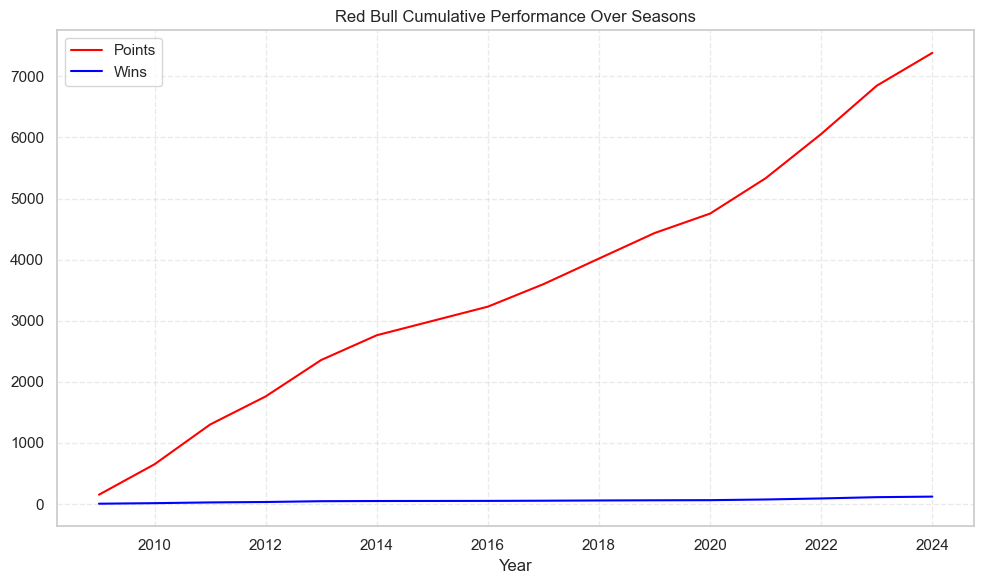

In [153]:
Season_Summary["cumulative_points"] = Season_Summary["Total Points"].cumsum()
Season_Summary["cumulative_wins"] = Season_Summary["wins"].cumsum()

plt.figure(figsize=(10, 6))
plt.plot(Season_Summary["year"], Season_Summary["cumulative_points"], label='Points', color='red')
plt.plot(Season_Summary["year"], Season_Summary["cumulative_wins"], label='Wins', color='blue')
plt.title("Red Bull Cumulative Performance Over Seasons")
plt.xlabel("Year")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("/Users/tanvi/Desktop/redbull_f1_eda/figures/cumulative_season_performance.png", dpi=300, bbox_inches="tight")
plt.show()


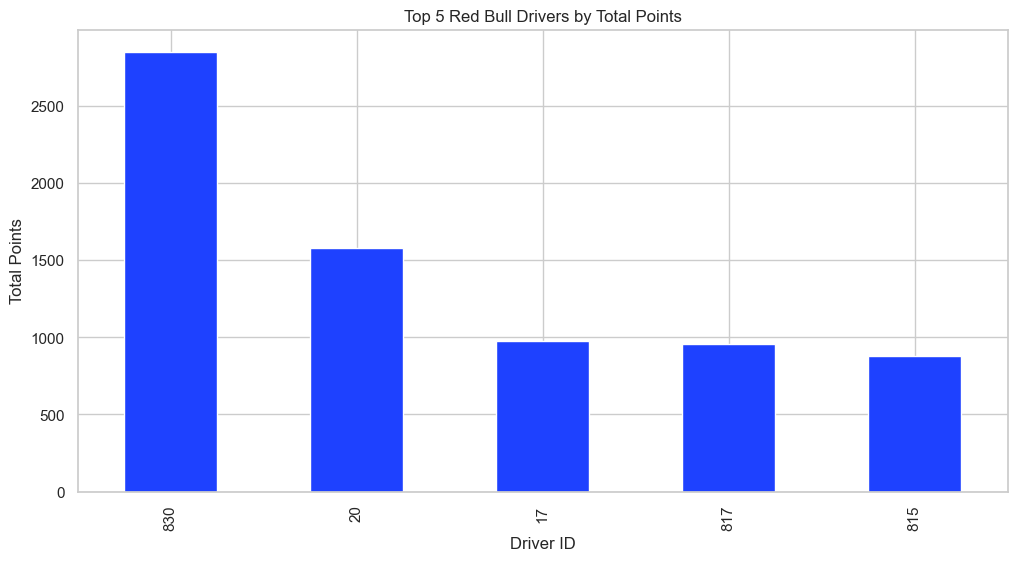

In [154]:
top_drivers = redbull_results.groupby('driverId')['points'].sum().sort_values(ascending=False).head(5)
top_drivers.plot(kind='bar', title='Top 5 Red Bull Drivers by Total Points', color = "#1E41FF")
plt.xlabel('Driver ID')
plt.ylabel('Total Points')
plt.savefig("/Users/tanvi/Desktop/redbull_f1_eda/figures/top5_rbdrivers.png", dpi=300, bbox_inches="tight")
plt.show()

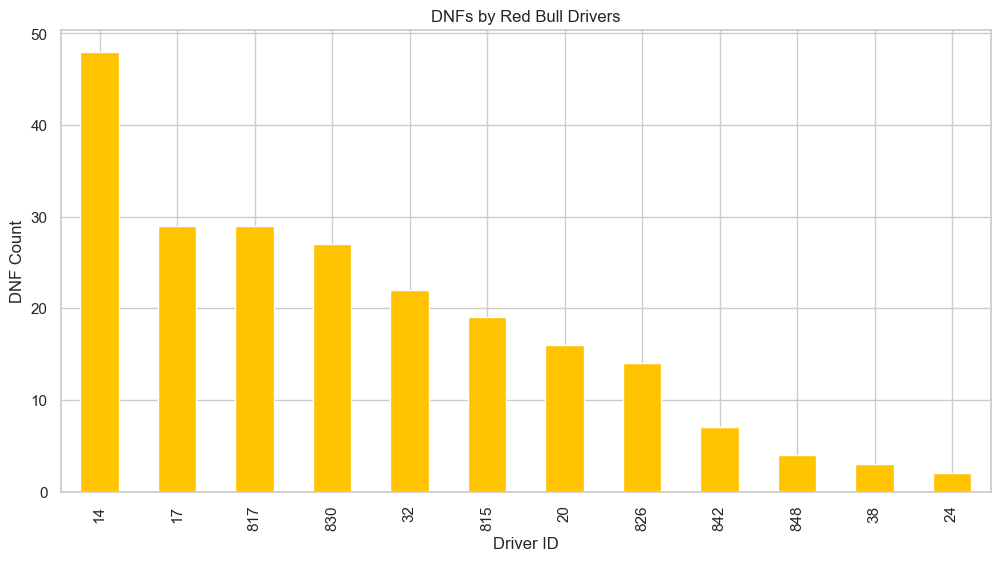

In [155]:
# Assuming statusId != 1 indicates DNF (you can confirm this from your status table)
dnf_counts = redbull_results[redbull_results['statusId'] != 1].groupby('driverId').size().sort_values(ascending=False)

dnf_counts.plot(kind='bar', title='DNFs by Red Bull Drivers', color="#FFC300")
plt.xlabel('Driver ID')
plt.ylabel('DNF Count')
plt.savefig("/Users/tanvi/Desktop/redbull_f1_eda/figures/DNFs_per_driverId.png", dpi=300, bbox_inches="tight")
plt.show()


### Conclusion

- Red Bull's podium finishes show a strong correlation with total points.
- Certain seasons (e.g. 2011, 2013, 2022+) had high podium consistency even if wins varied slightly.
- Drop in podiums around 2019 suggests mid-season inconsistency or reliability issues.


In [99]:

outcome = np.where(cleaned_redbull_results["positionOrder"]==1,"Win",(np.where(cleaned_redbull_results["positionOrder"]<=3, "Podium", "No Podium")))
cleaned_redbull_results["outcome"] = outcome

In [100]:
cleaned_redbull_results.columns


Index(['year', 'round', 'name', 'circuitId', 'driverId', 'points',
       'positionOrder', 'grid', 'statusId', 'fastestLapTime', 'laps',
       'outcome'],
      dtype='object')

In [101]:
model_df = cleaned_redbull_results[[ "grid","driverId","circuitId","fastestLapTime","statusId", "outcome"]].reset_index(drop=True)

In [102]:
model_df.info()
model_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 788 entries, 0 to 787
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   grid            788 non-null    int64 
 1   driverId        788 non-null    int64 
 2   circuitId       788 non-null    int64 
 3   fastestLapTime  788 non-null    object
 4   statusId        788 non-null    int64 
 5   outcome         788 non-null    object
dtypes: int64(4), object(2)
memory usage: 37.1+ KB


,grid,driverId,circuitId,fastestLapTime,statusId,outcome
0,8,14,1,1:29.502,4,No Podium
1,14,17,1,\N,4,No Podium
2,6,17,2,1:36.696,1,No Podium
3,12,14,2,1:36.206,1,No Podium
4,11,17,3,1:34.305,1,No Podium


In [106]:
def time_converter(time):
    if time == "\\N":
        return np.nan
    
    List = time.split(":")
    t1= float(List[0])*60
    t2= float(List[1])
    time_new = t1+t2
    return time_new
model_df["fastestLapSeconds"] = model_df["fastestLapTime"].apply(time_converter)


In [107]:
model_df["fastestLapSeconds"].isna().sum()

np.int64(37)

In [ ]:
model_df["fastestLapSeconds"]=model_df["fastestLapSeconds"].fillna(model_df["fastestLapSeconds"].median())

In [65]:

model_df.drop(columns=["fastestLapTime"], inplace=True)
model_df.head()


,grid,driverId,circuitId,statusId,outcome,fastestLapSeconds
0,8,14,1,4,No Podium,89.502
1,14,17,1,4,No Podium,89.600
2,6,17,2,1,No Podium,96.696
3,12,14,2,1,No Podium,96.206
4,11,17,3,1,No Podium,94.305


In [66]:
model_df["outcome_encoded"] = LabelEncoder().fit_transform(model_df["outcome"]) 
model_df["driverID_encoded"] = LabelEncoder().fit_transform(model_df["driverId"]) 
model_df["circuitID_encoded"] = LabelEncoder().fit_transform(model_df["circuitId"]) 
model_df["statusID_encoded"] = LabelEncoder().fit_transform(model_df["statusId"]) 

In [67]:
model_df.head()
model_df.columns


Index(['grid', 'driverId', 'circuitId', 'statusId', 'outcome',
       'fastestLapSeconds', 'outcome_encoded', 'driverID_encoded',
       'circuitID_encoded', 'statusID_encoded'],
      dtype='object')

## 🤖 Machine Learning Modeling
We build a predictive model using features from the dataset to classify or predict F1 race outcomes.

In [69]:
y = model_df["outcome_encoded"]
X = model_df[["grid", "fastestLapSeconds", "driverID_encoded", "circuitID_encoded", "statusID_encoded"]]

In [70]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [106]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.25,random_state=42)

In [111]:
Logistic_model = LogisticRegression(max_iter=500, random_state=42)
Logistic_model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [112]:
y_pred = Logistic_model.predict(X_test)
score = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy:", score)

Logistic Regression Accuracy: 0.751269035532995


In [97]:
Random_Classifier_model = RandomForestClassifier(random_state=42)
Random_Classifier_model.fit(X_train,y_train)
y_pred = Random_Classifier_model.predict(X_test)
score = accuracy_score(y_test, y_pred)
print("Random Classifier Accuracy:", score)

Random Classifier Accuracy: 0.7055837563451777


In [102]:
sample = pd.DataFrame([[2, 91.4, 1, 3, 0]], columns=X.columns)
prediction = Logistic_model.predict(sample)
decoded_label = model_df["outcome"].unique()[prediction[0]]

print("Prediction (encoded):", prediction[0])
print("Predicted Outcome:", decoded_label)

Prediction (encoded): 0
Predicted Outcome: No Podium


In [109]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [110]:
Logistic_model = LogisticRegression(max_iter=500, random_state=42)
Logistic_model.fit(X_train_scaled,y_train)
y_pred = Logistic_model.predict(X_test_scaled)
score = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy:", score)

Logistic Regression Accuracy: 0.7157360406091371


In [113]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(random_state=42)
gbc.fit(X_train, y_train)
y_pred_gbc = gbc.predict(X_test)
gbc_acc = accuracy_score(y_test, y_pred_gbc)
print("Gradient Boosting Accuracy:", gbc_acc)

Gradient Boosting Accuracy: 0.7157360406091371


In [114]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

In [115]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}

In [117]:
gbc = GradientBoostingClassifier(random_state=42)
gscv = GridSearchCV(estimator=gbc, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
gscv.fit(X_train_scaled, y_train)



Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.3s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.3s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.3s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.3s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.4s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.4s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.4s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.5s
[CV] END ..learning_rate=0.01, max_depth=5, n_estimators=100; total time=   0.4s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.5s
[CV] END ..learning_rate=0.01, max_depth=5, n_est

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.01, 0.1], 'max_depth': [3, 5], 'n_estimators': [100, 200]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [118]:
best_model = gscv.best_estimator_
y_pred = best_model.predict(X_test_scaled)
score = accuracy_score(y_test, y_pred)
print("Best Gradient Boosting Accuracy:", score)

Best Gradient Boosting Accuracy: 0.7461928934010152


## Model Selection and Accuracy

After testing multiple classification models including Random Forest and Gradient Boosting, **Logistic Regression** gave us the best accuracy on our test set:

| Model                | Accuracy   |
|----------------------|------------|
| Logistic Regression  | 0.7513     |
| Gradient Boosting    | 0.7462     |
| Random Forest       | 0.7056     |

Although Gradient Boosting came close, we will **stick with Logistic Regression** for this project because:

- It achieves the highest accuracy on the test data.
- It offers simplicity and interpretability.
- It trains and predicts faster, enabling quicker experimentation.

This choice helps us build an effective and explainable model for the Red Bull F1 results dataset.
